In [1]:
import gymnasium as gym
import numpy as np
import torch
from torch import nn
from dqn import Trainer
import pickle 

GAMMA = 0.99
TRUNC_LENGTH = 2000

In [2]:
# creating the modified environment
env = gym.make('MountainCar-v0', max_episode_steps=TRUNC_LENGTH)
seeds = [44, 63, 11, 15, 90, 21, 0, 12, 52, 8, 42, 32, 31, 10, 98]

In [ ]:
replay_factors = [1,2,4,8]
final_res = {}

for rho in replay_factors:
    final_res[rho] = []
    for s in seeds:
        env = gym.make('MountainCar-v0', max_episode_steps = TRUNC_LENGTH)

        dqn_trainer = Trainer(
            env = env,
            gamma = GAMMA,
            seed = s,
            use_wandb = True,
            wandb_project = "RL_PA2",
            wandb_run_name=f"q4_rho_{rho}_seed_{s}",
            trunc_length = TRUNC_LENGTH
        )

        returns = dqn_trainer.train(num_episodes=1500, replay_factor=rho)
        final_res[rho].append(returns)
        env.close()

#Q4 - replay factor analysis

In [ ]:
with open("q4_results.pkl", "wb") as f:
    pickle.dump(final_res, f)
print("Saved.")


In [3]:
replay_factors = [1,2,4,8]

with open("q4_results.pkl", "rb") as f:
    final_res = pickle.load(f)

print(len(final_res[1]), len(final_res[2]), len(final_res[4]), len(final_res[8]))

15 15 15 15


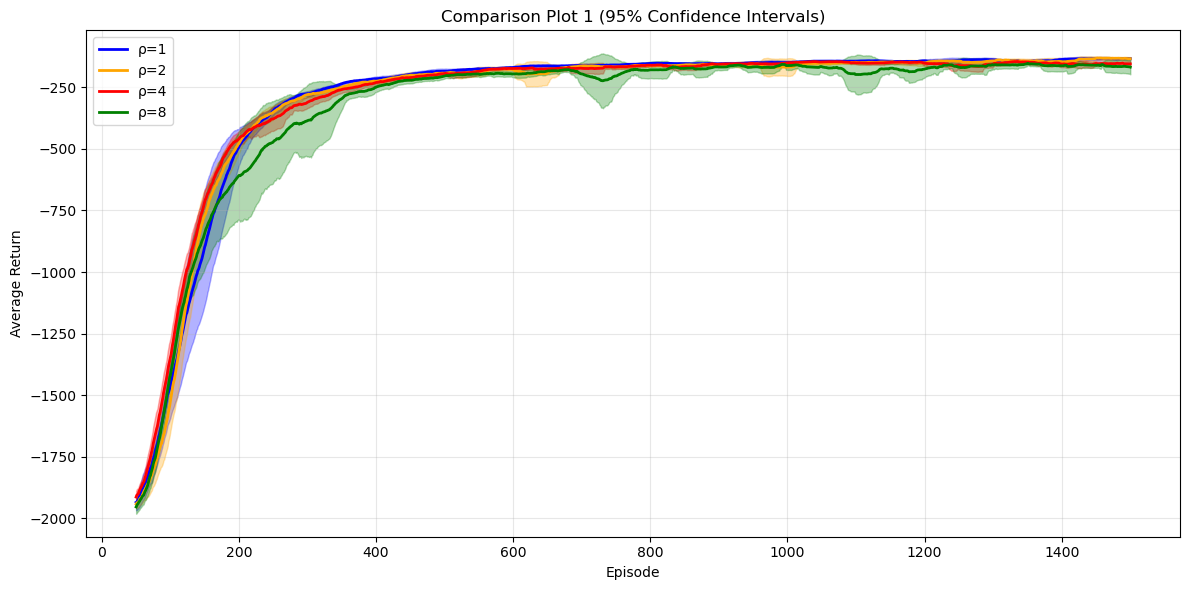

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

window_size = 50
colors = ['blue', 'orange', 'red', 'green']

plt.figure(figsize=(12, 6))
for rho, color in zip(replay_factors, colors):
    data = np.array(final_res[rho])
    smoothed = np.array([
        np.convolve(data[i], np.ones(window_size)/window_size, mode='valid')
        for i in range(len(data))
    ])  
    mean = smoothed.mean(axis=0)
    ci = stats.sem(smoothed, axis=0) * stats.t.ppf(0.975, df=len(data)-1)
    episodes = np.arange(window_size, data.shape[1] + 1)
    plt.plot(episodes, mean, label=f'ρ={rho}', color=color, linewidth=2)
    plt.fill_between(episodes, mean - ci, mean + ci, alpha=0.3, color=color)

plt.xlabel('Episode')
plt.ylabel('Average Return')
plt.title('Comparison Plot 1 (95% Confidence Intervals)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


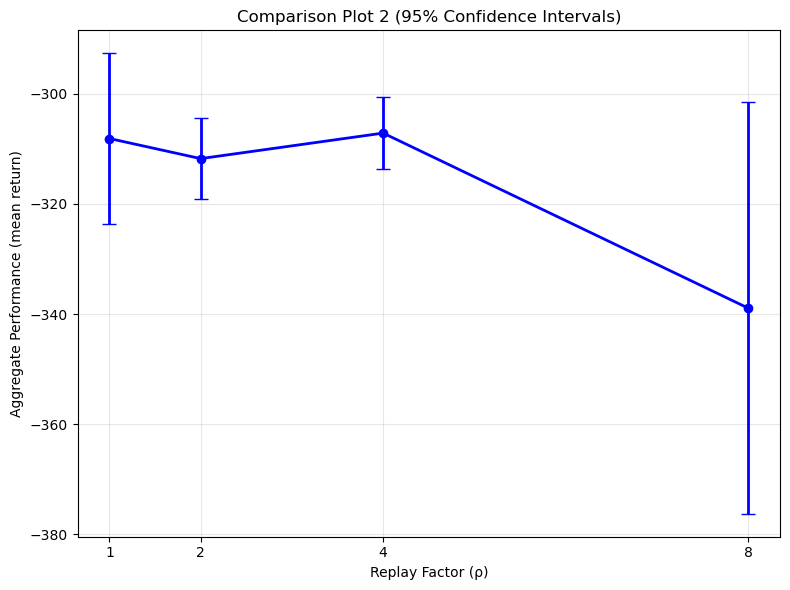

In [ ]:
aucs = {}
for rho in replay_factors:
    data = np.array(final_res[rho]) 
    aucs[rho] = data.mean(axis=1)  

means = [aucs[rho].mean() for rho in replay_factors]
cis = [stats.sem(aucs[rho]) * stats.t.ppf(0.975, df=14) for rho in replay_factors]

plt.figure(figsize=(8, 6))
plt.errorbar(replay_factors, means, yerr=cis, fmt='o-', linewidth=2,
             capsize=5, color='blue')
plt.xlabel('Replay Factor (ρ)')
plt.ylabel('Aggregate Performance (mean return)')
plt.title('Comparison Plot 2 (95% Confidence Intervals)')
plt.xticks(replay_factors)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy import stats

for rho in replay_factors:
    data = np.array(final_res[rho])   
    auc_per_seed = data.mean(axis=1)     
    mean = auc_per_seed.mean()
    ci = stats.sem(auc_per_seed) * stats.t.ppf(0.975, df=14)
    print(f"ρ={rho}: {mean:.2f} ± {ci:.2f}")


ρ=1: -308.15 ± 15.46
ρ=2: -311.80 ± 7.38
ρ=4: -307.17 ± 6.56
ρ=8: -338.92 ± 37.32
